In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from catboost import CatBoostRegressor

from lightgbm import LGBMRegressor

from xgboost import XGBRegressor

from sklearn.ensemble import (

    RandomForestRegressor,

    ExtraTreesRegressor

)

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load Processed Datasets

X_train = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
)

In [3]:
# Dataset Verification

print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (79913, 31)
Testing Features : (19979, 31)
Training Target : (79913, 1)
Testing Target : (19979, 1)


In [4]:
# Remove Identifier Columns

identifier_columns = [

    "Run",

    "Event"

]

X_train = X_train.drop(

    columns=identifier_columns,

    errors="ignore"

)

X_test = X_test.drop(

    columns=identifier_columns,

    errors="ignore"

)

print("Identifier Columns Removed")

Identifier Columns Removed


In [5]:
# Convert Target Variables to Series

y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [6]:
# Load Best Model

best_model = joblib.load(

    "../models/best_model.pkl"

)

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


In [7]:
# Load Best Model Information

best_model_summary = pd.read_csv(

    "../results/best_model_summary.csv"

)

best_model_name = best_model_summary.loc[

    0,

    "Model"

]

print("Best Model :", best_model_name)

Best Model : CatBoost


In [8]:
# Calculate Feature Importance

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

).reset_index(

    drop=True

)

display(feature_importance)

,Feature,Importance
0,Eta_Difference,29.363339
1,Total_PT,29.286672
2,Cos_Theta,10.609399
3,Total_Energy,7.091819
4,E1,5.380311
5,Phi_Difference,3.692992
6,Momentum2,3.671256
7,PT_Difference,2.424871
8,Momentum1,2.332363
9,pt1,2.231988


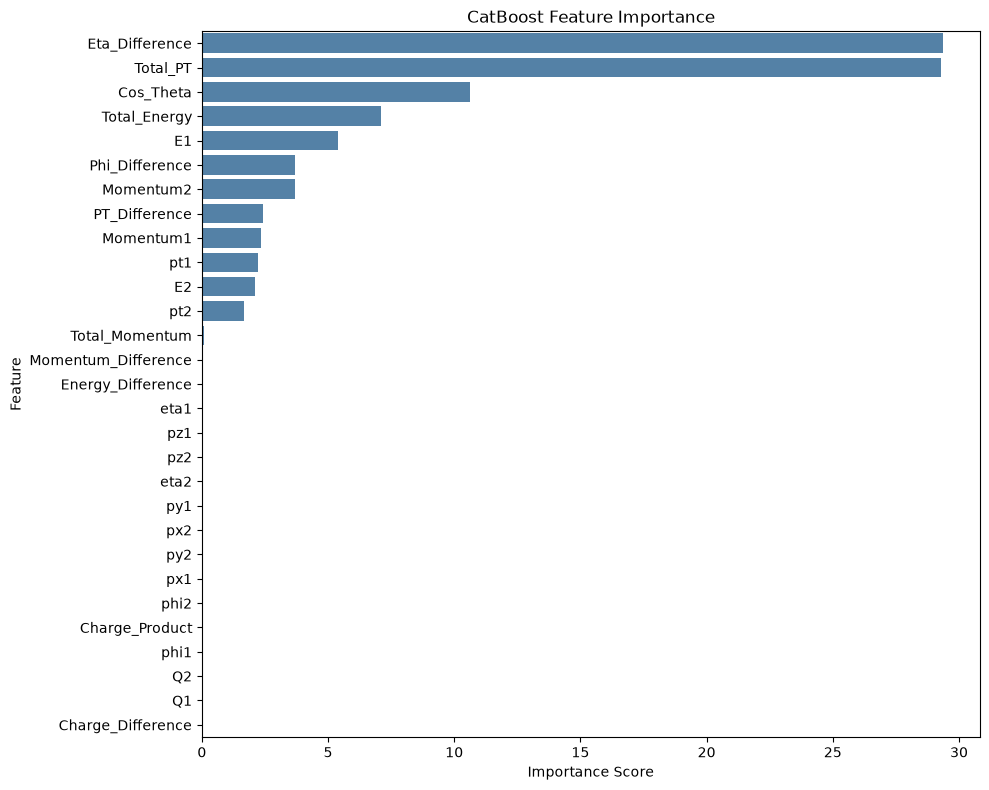

In [9]:
# Visualize Feature Importance

plt.figure(figsize=(10, 8))

sns.barplot(

    data=feature_importance,

    x="Importance",

    y="Feature",

    color="steelblue"

)

plt.title("CatBoost Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [10]:
# Display Most Important Sensors

display(

    feature_importance.head(10)

)

,Feature,Importance
0,Eta_Difference,29.363339
1,Total_PT,29.286672
2,Cos_Theta,10.609399
3,Total_Energy,7.091819
4,E1,5.380311
5,Phi_Difference,3.692992
6,Momentum2,3.671256
7,PT_Difference,2.424871
8,Momentum1,2.332363
9,pt1,2.231988


In [11]:
# Save Feature Importance

os.makedirs(

    "../results",

    exist_ok=True

)

feature_importance.to_csv(

    "../results/feature_importance.csv",

    index=False

)

print("Feature Importance Saved Successfully")

Feature Importance Saved Successfully


In [12]:
# Calculate Permutation Importance

permutation = permutation_importance(

    estimator=best_model,

    X=X_test,

    y=y_test,

    scoring="neg_root_mean_squared_error",

    n_repeats=10,

    random_state=42,

    n_jobs=-1

)

In [13]:
# Create Permutation Importance Table

permutation_importance_df = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance": permutation.importances_mean,

    "Standard Deviation": permutation.importances_std

})

permutation_importance_df = permutation_importance_df.sort_values(

    by="Importance",

    ascending=False

).reset_index(

    drop=True

)

display(permutation_importance_df)

,Feature,Importance,Standard Deviation
0,Eta_Difference,14.223749,0.053890
1,Total_PT,13.282223,0.035332
2,Cos_Theta,10.443369,0.063797
3,Total_Energy,10.072979,0.055365
4,E1,4.558053,0.032111
5,pt1,3.403529,0.042498
6,pt2,3.355608,0.024931
7,Momentum2,3.355403,0.031599
8,Phi_Difference,3.325797,0.037943
9,Momentum1,2.433246,0.015146


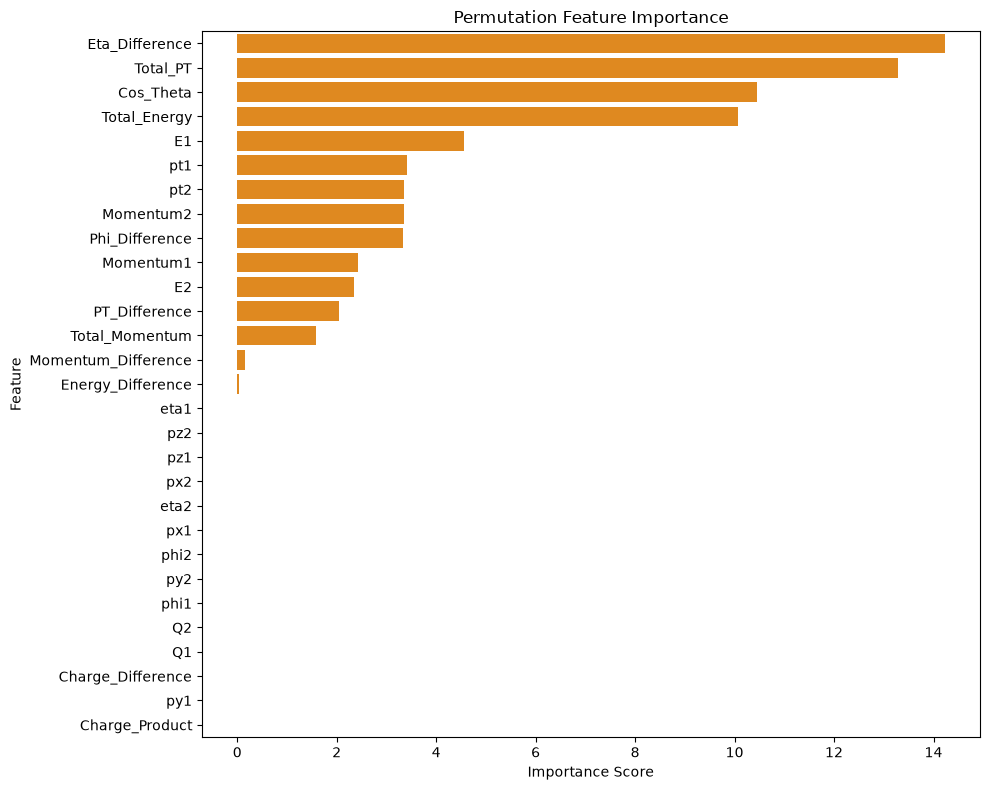

In [14]:
# Visualize Permutation Importance

plt.figure(figsize=(10, 8))

sns.barplot(

    data=permutation_importance_df,

    x="Importance",

    y="Feature",

    color="darkorange"

)

plt.title("Permutation Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [15]:
# Display Most Important Sensors

display(

    permutation_importance_df.head(10)

)

,Feature,Importance,Standard Deviation
0,Eta_Difference,14.223749,0.053890
1,Total_PT,13.282223,0.035332
2,Cos_Theta,10.443369,0.063797
3,Total_Energy,10.072979,0.055365
4,E1,4.558053,0.032111
5,pt1,3.403529,0.042498
6,pt2,3.355608,0.024931
7,Momentum2,3.355403,0.031599
8,Phi_Difference,3.325797,0.037943
9,Momentum1,2.433246,0.015146


In [16]:
# Save Permutation Importance

permutation_importance_df.to_csv(

    "../results/permutation_importance.csv",

    index=False

)

print("Permutation Importance Saved Successfully")

Permutation Importance Saved Successfully


In [17]:
# Create a Sample for SHAP Analysis

X_shap = X_test.sample(

    n=1000,

    random_state=42

)

In [18]:
# Initialize SHAP Explainer

explainer = shap.TreeExplainer(

    best_model

)

In [19]:
# Calculate SHAP Values

shap_values = explainer.shap_values(

    X_shap

)

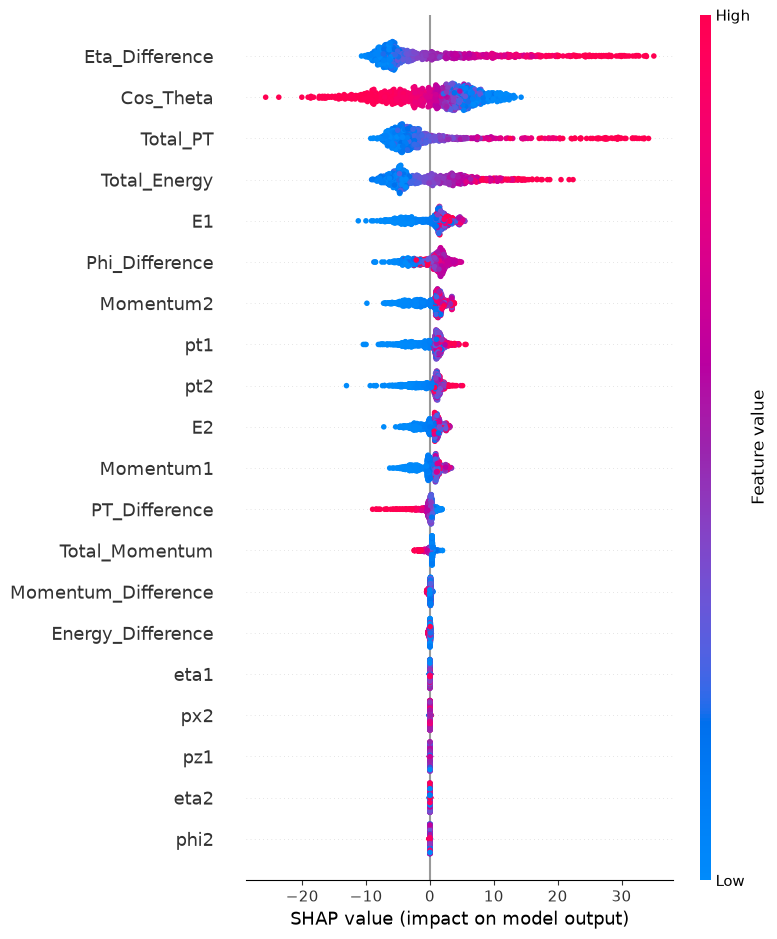

In [20]:
# Visualize SHAP Summary Plot

shap.summary_plot(

    shap_values,

    X_shap,

    show=False

)

plt.tight_layout()

plt.show()

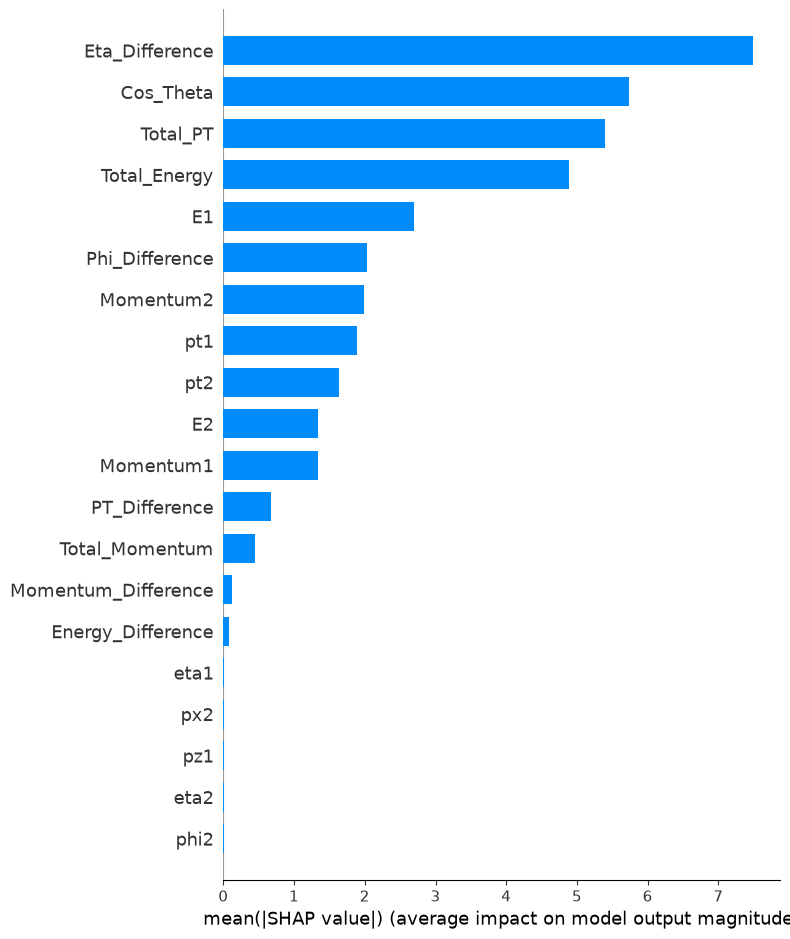

In [21]:
# Visualize SHAP Feature Importance

shap.summary_plot(

    shap_values,

    X_shap,

    plot_type="bar",

    show=False

)

plt.tight_layout()

plt.show()

In [22]:
# Create SHAP Importance Table

shap_importance = pd.DataFrame({

    "Feature": X_shap.columns,

    "Importance": np.abs(

        shap_values

    ).mean(

        axis=0

    )

})

shap_importance = shap_importance.sort_values(

    by="Importance",

    ascending=False

).reset_index(

    drop=True

)

display(shap_importance)

,Feature,Importance
0,Eta_Difference,7.496306
1,Cos_Theta,5.736100
2,Total_PT,5.398669
3,Total_Energy,4.885698
4,E1,2.689474
5,Phi_Difference,2.037448
6,Momentum2,1.982679
7,pt1,1.885672
8,pt2,1.639211
9,E2,1.340292


In [23]:
# Save SHAP Importance

shap_importance.to_csv(

    "../results/shap_importance.csv",

    index=False

)

print("SHAP Importance Saved Successfully")

SHAP Importance Saved Successfully


In [24]:
# Combine Feature Importance Scores

consensus_importance = feature_importance.rename(

    columns={

        "Importance": "CatBoost"

    }

).merge(

    permutation_importance_df[

        [

            "Feature",

            "Importance"

        ]

    ].rename(

        columns={

            "Importance": "Permutation"

        }

    ),

    on="Feature"

).merge(

    shap_importance.rename(

        columns={

            "Importance": "SHAP"

        }

    ),

    on="Feature"

)

In [25]:
# Normalize Importance Scores

importance_columns = [

    "CatBoost",

    "Permutation",

    "SHAP"

]

for column in importance_columns:

    consensus_importance[column] = (

        consensus_importance[column]

        /

        consensus_importance[column].max()

    )

In [26]:
# Calculate Consensus Importance Score

consensus_importance["Consensus"] = (

    consensus_importance[

        importance_columns

    ].mean(

        axis=1

    )

)

In [27]:
# Rank Sensors

consensus_importance = consensus_importance.sort_values(

    by="Consensus",

    ascending=False

).reset_index(

    drop=True

)

display(consensus_importance)

,Feature,CatBoost,Permutation,SHAP,Consensus
0,Eta_Difference,1.000000,1.000000,1.000000,1.000000
1,Total_PT,0.997389,0.933806,0.720177,0.883791
2,Cos_Theta,0.361314,0.734221,0.765190,0.620242
3,Total_Energy,0.241520,0.708180,0.651747,0.533816
4,E1,0.183232,0.320454,0.358773,0.287486
5,Phi_Difference,0.125769,0.233820,0.271794,0.210461
6,Momentum2,0.125029,0.235901,0.264487,0.208472
7,pt1,0.076013,0.239285,0.251547,0.188948
8,pt2,0.057015,0.235916,0.218669,0.170533
9,Momentum1,0.079431,0.171069,0.178223,0.142908


In [28]:
# Display Most Important Sensors

display(

    consensus_importance.head(10)

)

,Feature,CatBoost,Permutation,SHAP,Consensus
0,Eta_Difference,1.000000,1.000000,1.000000,1.000000
1,Total_PT,0.997389,0.933806,0.720177,0.883791
2,Cos_Theta,0.361314,0.734221,0.765190,0.620242
3,Total_Energy,0.241520,0.708180,0.651747,0.533816
4,E1,0.183232,0.320454,0.358773,0.287486
5,Phi_Difference,0.125769,0.233820,0.271794,0.210461
6,Momentum2,0.125029,0.235901,0.264487,0.208472
7,pt1,0.076013,0.239285,0.251547,0.188948
8,pt2,0.057015,0.235916,0.218669,0.170533
9,Momentum1,0.079431,0.171069,0.178223,0.142908


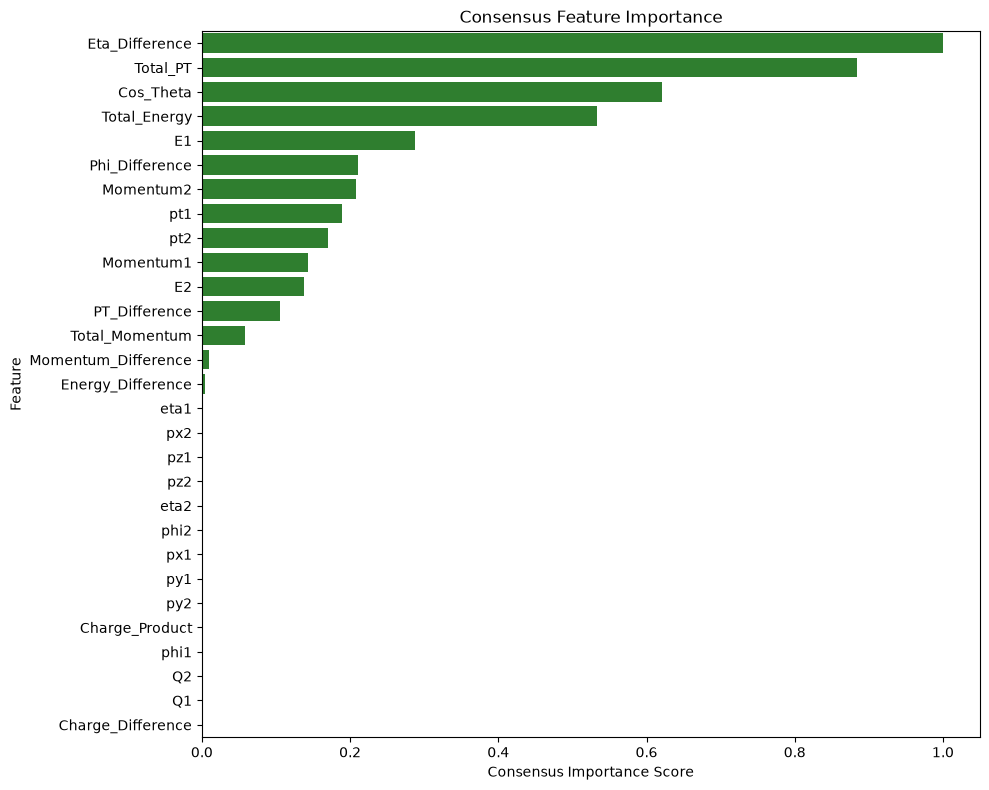

In [29]:
# Visualize Consensus Feature Importance

plt.figure(figsize=(10,8))

sns.barplot(

    data=consensus_importance,

    x="Consensus",

    y="Feature",

    color="forestgreen"

)

plt.title("Consensus Feature Importance")

plt.xlabel("Consensus Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [30]:
# Save Consensus Feature Importance

consensus_importance.to_csv(

    "../results/consensus_feature_importance.csv",

    index=False

)

print("Consensus Feature Importance Saved Successfully")

Consensus Feature Importance Saved Successfully


In [31]:
# Define Sensor Subsets

feature_counts = [

    len(consensus_importance),

    15,

    12,

    10,

    8,

    5

]

feature_counts = [

    count

    for count in feature_counts

    if count <= len(consensus_importance)

]

In [32]:
# Initialize Model for Sensor Purging

if best_model_name == "CatBoost":

    model_class = CatBoostRegressor

    model_parameters = {

        "random_state": 42,

        "verbose": 0

    }

elif best_model_name == "LightGBM":

    model_class = LGBMRegressor

    model_parameters = {

        "random_state": 42

    }

elif best_model_name == "XGBoost":

    model_class = XGBRegressor

    model_parameters = {

        "random_state": 42,

        "verbosity": 0

    }

elif best_model_name == "Extra Trees":

    model_class = ExtraTreesRegressor

    model_parameters = {

        "random_state": 42,

        "n_jobs": -1

    }

elif best_model_name == "Random Forest":

    model_class = RandomForestRegressor

    model_parameters = {

        "random_state": 42,

        "n_jobs": -1

    }

else:

    raise ValueError(

        f"Unsupported Model: {best_model_name}"

    )

In [33]:
# Evaluate Different Sensor Sets

sensor_results = []

for count in feature_counts:

    selected_features = (

        consensus_importance["Feature"]

        .head(count)

        .tolist()

    )

    model = model_class(

        **model_parameters

    )

    model.fit(

        X_train[selected_features],

        y_train

    )

    predictions = model.predict(

        X_test[selected_features]

    )

    mae = mean_absolute_error(

        y_test,

        predictions

    )

    rmse = np.sqrt(

        mean_squared_error(

            y_test,

            predictions

        )

    )

    r2 = r2_score(

        y_test,

        predictions

    )

    sensor_results.append({

        "Sensors": count,

        "MAE": mae,

        "RMSE": rmse,

        "R²": r2

    })

print("Sensor Purging Completed")

Sensor Purging Completed


In [34]:
# Create Sensor Purging Results

sensor_results_df = pd.DataFrame(

    sensor_results

)

display(sensor_results_df)

,Sensors,MAE,RMSE,R²
0,29,0.515528,0.833124,0.998911
1,15,0.519090,0.817650,0.998951
2,12,0.515804,0.813986,0.998961
3,10,0.511291,0.815332,0.998957
4,8,0.554217,0.873353,0.998803
5,5,1.103516,2.173971,0.992585


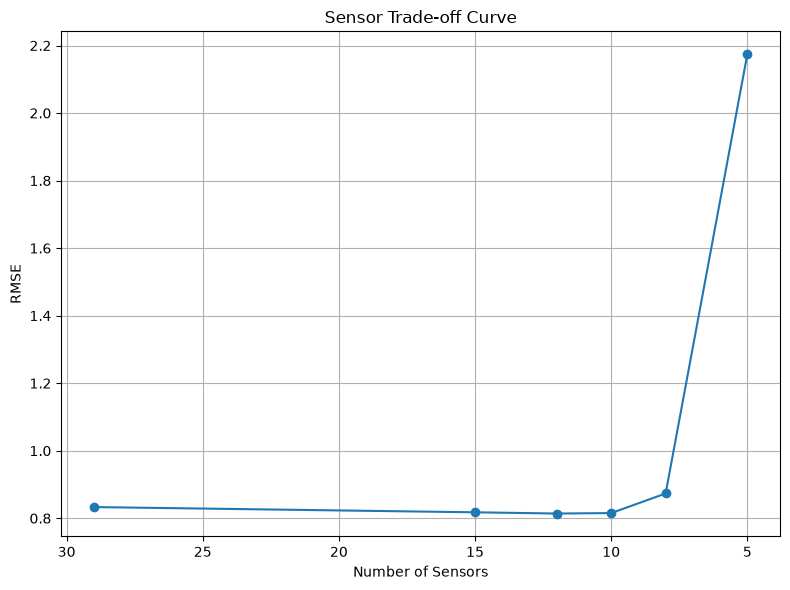

In [35]:
# Visualize Sensor Trade-off

plt.figure(figsize=(8,6))

plt.plot(

    sensor_results_df["Sensors"],

    sensor_results_df["RMSE"],

    marker="o"

)

plt.gca().invert_xaxis()

plt.title(

    "Sensor Trade-off Curve"

)

plt.xlabel(

    "Number of Sensors"

)

plt.ylabel(

    "RMSE"

)

plt.grid(True)

plt.tight_layout()

plt.show()

In [36]:
# Recommend Optimal Sensor Set

baseline_rmse = sensor_results_df.iloc[0]["RMSE"]

sensor_results_df["RMSE Increase (%)"] = (

    (

        sensor_results_df["RMSE"]

        - baseline_rmse

    )

    /

    baseline_rmse

) * 100

display(sensor_results_df)

,Sensors,MAE,RMSE,R²,RMSE Increase (%)
0,29,0.515528,0.833124,0.998911,0.000000
1,15,0.519090,0.817650,0.998951,-1.857369
2,12,0.515804,0.813986,0.998961,-2.297169
3,10,0.511291,0.815332,0.998957,-2.135590
4,8,0.554217,0.873353,0.998803,4.828631
5,5,1.103516,2.173971,0.992585,160.941980


In [37]:
# Save Sensor Purging Results

sensor_results_df.to_csv(

    "../results/sensor_purging_results.csv",

    index=False

)

print("Sensor Purging Results Saved Successfully")

Sensor Purging Results Saved Successfully


In [38]:
# Save Recommended Sensors

selected_features = consensus_importance[

    "Feature"

].head(

    10

)

selected_features.to_csv(

    "../results/selected_features.csv",

    index=False

)

print("Selected Sensors Saved Successfully")

Selected Sensors Saved Successfully
